In [2]:
# importing needed packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#read in csv
sac_data = pd.read_csv("sacstations.csv")

/var/folders/_r/k4drv0q16vb4s0cfjxzhbc180000gn/T/ipykernel_54554/1338895190.py:2: DtypeWarning: Columns (8,10,11,13,16,19,25,26,27,28,29,31,32,33,34,36,37,42,43,44,45,48,50,52,54,71,72,73,74,75,91,92,96,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,125) have mixed types. Specify dtype option on import or set low_memory=False.
  sac_data = pd.read_csv("sacstations.csv")


In [4]:
# print all column names
for col in sac_data.columns:
    print(col)

STATION
NAME
LATITUDE
LONGITUDE
ELEVATION
DATE
REPORT_TYPE
SOURCE
BackupDirection
BackupDistance
BackupDistanceUnit
BackupElements
BackupElevation
BackupEquipment
BackupLatitude
BackupLongitude
BackupName
CoolingDegreeDaysSeasonToDate
DailyAverageDewPointTemperature
DailyAverageDryBulbTemperature
DailyAverageRelativeHumidity
DailyAverageSeaLevelPressure
DailyAverageStationPressure
DailyAverageWetBulbTemperature
DailyAverageWindSpeed
DailyCoolingDegreeDays
DailyDepartureFromNormalAverageTemperature
DailyHeatingDegreeDays
DailyMaximumDryBulbTemperature
DailyMinimumDryBulbTemperature
DailyPeakWindDirection
DailyPeakWindSpeed
DailyPrecipitation
DailySnowDepth
DailySnowfall
DailySustainedWindDirection
DailySustainedWindSpeed
DailyWeather
HeatingDegreeDaysSeasonToDate
HourlyAltimeterSetting
HourlyDewPointTemperature
HourlyDryBulbTemperature
HourlyPrecipitation
HourlyPresentWeatherType
HourlyPressureChange
HourlyPressureTendency
HourlyRelativeHumidity
HourlySeaLevelPressure
HourlySkyCondition

In [5]:
#just look at columns with values we need
sel_sac_columns = ["HourlyDryBulbTemperature", "HourlyPrecipitation", "HourlySkyConditions","MonthlyNumberDaysWithHeavyFog"]

sel_sac_data = sac_data[sel_sac_columns]
print(sel_sac_data)

         HourlyDryBulbTemperature HourlyPrecipitation HourlySkyConditions  \
0                             NaN                 NaN                 NaN   
1                             NaN                 NaN                 NaN   
2                             NaN                 NaN                 NaN   
3                             NaN                 NaN                 NaN   
4                             NaN                 NaN                 NaN   
...                           ...                 ...                 ...   
3195233                       8.9                 NaN                 NaN   
3195234                       9.4                 NaN                 NaN   
3195235                      12.8                 NaN                 NaN   
3195236                      15.6                 NaN                 NaN   
3195237                      17.8                 NaN                 NaN   

         MonthlyNumberDaysWithHeavyFog  
0                                 

In [6]:
notna_rows = sel_sac_data[sel_sac_data.notna().any(axis=1)]
print(notna_rows)

         HourlyDryBulbTemperature HourlyPrecipitation HourlySkyConditions  \
5829                          5.6                 NaN                 NaN   
5830                          5.6                 NaN                 NaN   
5831                          7.3                 NaN                 NaN   
5832                          7.3                 NaN                 NaN   
5834                          4.4                 NaN                 NaN   
...                           ...                 ...                 ...   
3195233                       8.9                 NaN                 NaN   
3195234                       9.4                 NaN                 NaN   
3195235                      12.8                 NaN                 NaN   
3195236                      15.6                 NaN                 NaN   
3195237                      17.8                 NaN                 NaN   

         MonthlyNumberDaysWithHeavyFog  
5829                              

In [7]:

only_fog = sac_data["MonthlyNumberDaysWithHeavyFog"]
fog_rows = only_fog[only_fog.notna()]
print(fog_rows)

110362      1.0
2092607    15.0
2093308     2.0
2094084     4.0
2094834     2.0
           ... 
3183259     3.0
3184283    13.0
3185112     3.0
3185904     2.0
3186742     3.0
Name: MonthlyNumberDaysWithHeavyFog, Length: 410, dtype: float64


In [8]:
#okay so we do have some days with fog.... let's plot by day
date_fog_columns = ["DATE", "MonthlyNumberDaysWithHeavyFog"]

date_fog_data = sac_data[date_fog_columns]
print(date_fog_data)

                        DATE  MonthlyNumberDaysWithHeavyFog
0        1877-07-11T00:00:00                            NaN
1        1877-07-12T00:00:00                            NaN
2        1877-07-13T00:00:00                            NaN
3        1877-07-14T00:00:00                            NaN
4        1877-07-15T00:00:00                            NaN
...                      ...                            ...
3195233  2026-02-05T09:41:00                            NaN
3195234  2026-02-05T09:53:00                            NaN
3195235  2026-02-05T10:53:00                            NaN
3195236  2026-02-05T11:53:00                            NaN
3195237  2026-02-05T12:53:00                            NaN

[3195238 rows x 2 columns]


In [10]:
fog_rows2 = date_fog_data[date_fog_data.notna().all(axis=1)]
print(fog_rows2)

                        DATE  MonthlyNumberDaysWithHeavyFog
110362   2020-01-31T23:59:00                            1.0
2092607  1965-01-31T23:59:00                           15.0
2093308  1965-02-28T23:59:00                            2.0
2094084  1965-03-31T23:59:00                            4.0
2094834  1965-04-30T23:59:00                            2.0
...                      ...                            ...
3183259  2024-11-30T23:59:00                            3.0
3184283  2024-12-31T23:59:00                           13.0
3185112  2025-01-31T23:59:00                            3.0
3185904  2025-02-28T23:59:00                            2.0
3186742  2025-03-31T23:59:00                            3.0

[410 rows x 2 columns]


<Axes: xlabel='MonthlyNumberDaysWithHeavyFog', ylabel='DATE'>

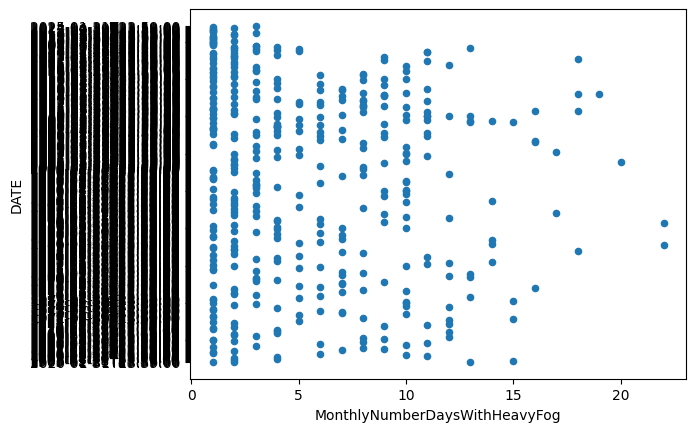

In [ ]:
#ugly plot to see what's up
fog_rows2.plot(x = "MonthlyNumberDaysWithHeavyFog", y = "DATE", kind = 'scatter')

In [15]:
#but we can't see anything!! Let's try something else
fog_rows2["DATE"] = pd.to_datetime(fog_rows2["DATE"])

/var/folders/_r/k4drv0q16vb4s0cfjxzhbc180000gn/T/ipykernel_54554/457023298.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fog_rows2["DATE"] = pd.to_datetime(fog_rows2["DATE"])


In [16]:
fog_rows2["year"] = fog_rows2["DATE"].dt.year
fog_rows2["month"] = fog_rows2["DATE"].dt.month
print(fog_rows2.head(5))

                       DATE  MonthlyNumberDaysWithHeavyFog  year  month
110362  2020-01-31 23:59:00                            1.0  2020      1
2092607 1965-01-31 23:59:00                           15.0  1965      1
2093308 1965-02-28 23:59:00                            2.0  1965      2
2094084 1965-03-31 23:59:00                            4.0  1965      3
2094834 1965-04-30 23:59:00                            2.0  1965      4


/var/folders/_r/k4drv0q16vb4s0cfjxzhbc180000gn/T/ipykernel_54554/4177859430.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fog_rows2["year"] = fog_rows2["DATE"].dt.year
/var/folders/_r/k4drv0q16vb4s0cfjxzhbc180000gn/T/ipykernel_54554/4177859430.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fog_rows2["month"] = fog_rows2["DATE"].dt.month


<Axes: xlabel='month', ylabel='year'>

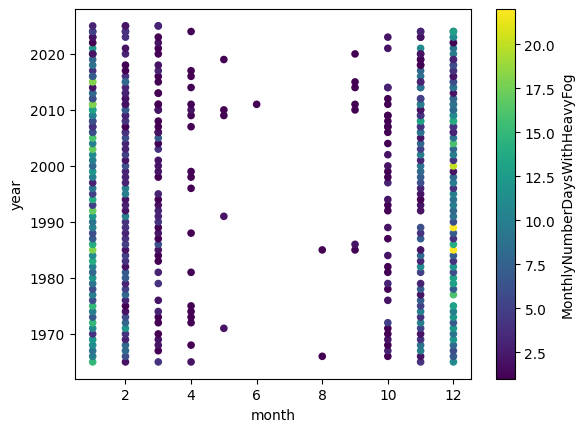

In [ ]:
#we can tell when the fog season is from this plot
fog_rows2.plot(x = "month", y = "year", c = "MonthlyNumberDaysWithHeavyFog", kind = 'scatter')

In [20]:
year_total = fog_rows2.groupby(['year'])['month'].sum().rename('total_days').reset_index()
print(year_total)

    year  total_days
0   1965          33
1   1966          44
2   1967          39
3   1968          43
4   1969          39
..   ...         ...
56  2021          39
57  2022          29
58  2023          63
59  2024          56
60  2025          11

[61 rows x 2 columns]


<Axes: xlabel='year'>

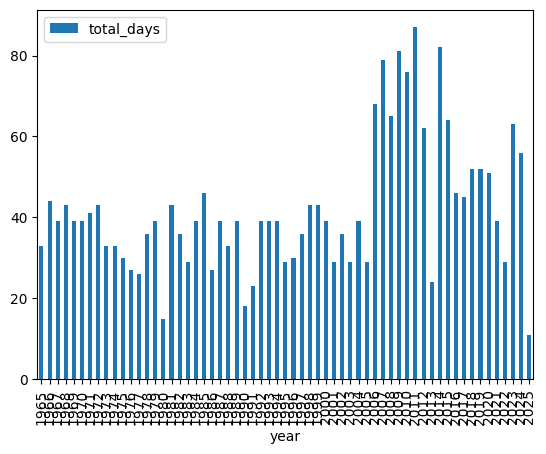

In [23]:
year_total.plot(x = 'year', y = 'total_days',kind = 'bar')

Text(0.5, 1.0, 'Total number of days with heavy fog per year')

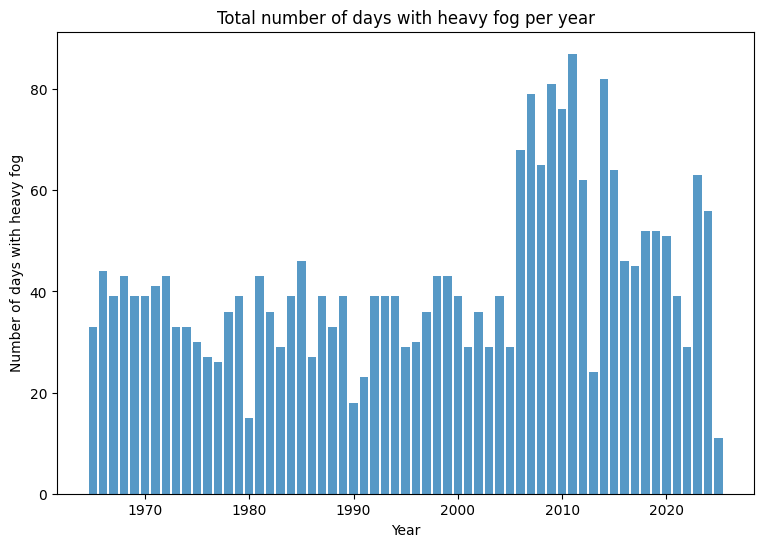

In [27]:
#prettier plot
fig1, ax1 = plt.subplots(figsize=(9, 6))

sc1 = ax1.bar(
    year_total["year"],
    year_total["total_days"],
    alpha=0.75
)
# Set customizations
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of days with heavy fog")
ax1.set_title("Total number of days with heavy fog per year")


In [ ]:
#but this probably isn't most helpful as I should split the data along the fog season...